In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import OLS, add_constant
from scipy.stats import shapiro
import re
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [10]:
data = pd.read_csv('ChurnData.csv')
data.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


## Part-1

In [11]:
print(data.isnull().sum())

data=data.dropna()  

selected_columns=['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard', 'wireless', 'churn']
data=data[selected_columns]

scaler=StandardScaler()
data[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard', 'wireless']] = scaler.fit_transform(data[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard', 'wireless']])

X=data.drop('churn', axis=1)
y=data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model=LogisticRegression(solver='liblinear', C=0.01)

model.fit(X_train, y_train)

probs=model.predict_proba(X_test)

print(probs[:5])  

tenure      0
age         0
address     0
income      0
ed          0
employ      0
equip       0
callcard    0
wireless    0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
longten     0
tollten     0
cardten     0
voice       0
pager       0
internet    0
callwait    0
confer      0
ebill       0
loglong     0
logtoll     0
lninc       0
custcat     0
churn       0
dtype: int64
[[0.4702986  0.5297014 ]
 [0.34856966 0.65143034]
 [0.58608564 0.41391436]
 [0.58300462 0.41699538]
 [0.53127753 0.46872247]]


## Part-2


log loss:  0.547208369277041

confusion matrix:
  [[24  7]
 [ 3  6]]


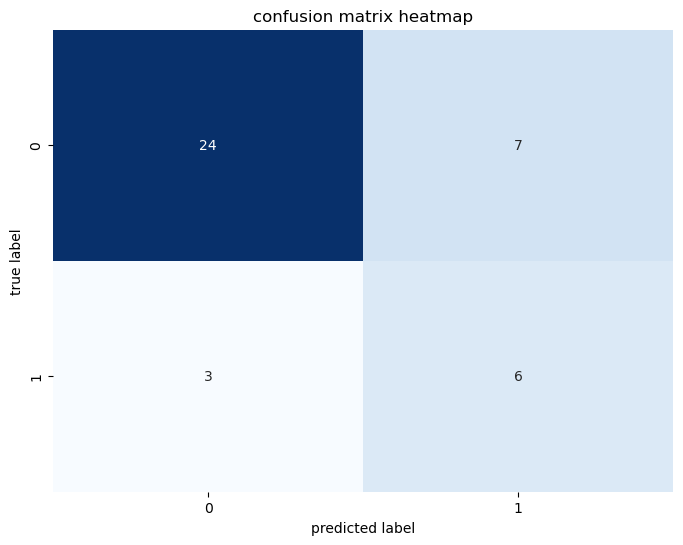


accuracy:  0.75

precision:  0.46153846153846156

recall:  0.6666666666666666

f1-score:  0.5454545454545455

specificity:  0.7741935483870968


In [13]:
logloss=log_loss(y_test, probs)
print("\nlog loss: ", logloss)

y_pred=model.predict(X_test)

cm=confusion_matrix(y_test, y_pred)
print("\nconfusion matrix:\n ", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("confusion matrix heatmap")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.show()


accuracy=accuracy_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)

tn, fp, fn, tp=cm.ravel()
specificity=tn/(tn+fp)

print("\naccuracy: ", accuracy)
print("\nprecision: ", precision)
print("\nrecall: ", recall)
print("\nf1-score: ", f1)
print("\nspecificity: ", specificity)

## Part-3

In [14]:
Cval=float(input("enter value for regularization parameter C: "))

model=LogisticRegression(solver='newton-cg', C=Cval) 
model2=LogisticRegression(solver='lbfgs', C=Cval) 
model3=LogisticRegression(solver='liblinear', C=Cval) 
model4=LogisticRegression(solver='sag', C=Cval) 
model5=LogisticRegression(solver='saga', C=Cval) 

choice=int(input("\nenter model (1 for newton-cg, 2 for lbfgs, 3 for liblinear, 4 for sag, 5 for saga, 6 for regularisation C: "))

if choice==1:
    model.fit(X_train, y_train)

    probs=model.predict_proba(X_test)
    logloss=log_loss(y_test, probs)
    y_pred=model.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    
    cm=confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp=cm.ravel()
    specificity=tn/(tn+fp)
    
    print("\nlog loss: ", logloss)
    print("\naccuracy: ", accuracy)
    print("\nprecision: ", precision)
    print("\nrecall: ", recall)
    print("\nf1-score: ", f1)
    print("\nspecificity: ", specificity)
elif choice==2:
    model2.fit(X_train, y_train)

    probs=model2.predict_proba(X_test)
    logloss=log_loss(y_test, probs)
    y_pred=model2.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    
    cm=confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp=cm.ravel()
    specificity=tn/(tn+fp)
    
    print("\nlog loss: ", logloss)
    print("\naccuracy: ", accuracy)
    print("\nprecision: ", precision)
    print("\nrecall: ", recall)
    print("\nf1-score: ", f1)
    print("\nspecificity: ", specificity)
elif choice==3:
    model3.fit(X_train, y_train)

    probs=model3.predict_proba(X_test)
    logloss=log_loss(y_test, probs)
    y_pred=model3.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    
    cm=confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp=cm.ravel()
    specificity=tn/(tn+fp)
    
    print("\nlog loss: ", logloss)
    print("\naccuracy: ", accuracy)
    print("\nprecision: ", precision)
    print("\nrecall: ", recall)
    print("\nf1-score: ", f1)
    print("\nspecificity: ", specificity)
elif choice==4:
    model4.fit(X_train, y_train)

    probs=model4.predict_proba(X_test)
    logloss=log_loss(y_test, probs)
    y_pred=model4.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    
    cm=confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp=cm.ravel()
    specificity=tn/(tn+fp)
    
    print("\nlog loss: ", logloss)
    print("\naccuracy: ", accuracy)
    print("\nprecision: ", precision)
    print("\nrecall: ", recall)
    print("\nf1-score: ", f1)
    print("\nspecificity: ", specificity)
elif choice==5:
    model5.fit(X_train, y_train)

    probs=model5.predict_proba(X_test)
    logloss=log_loss(y_test, probs)
    y_pred=model5.predict(X_test)
    
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    
    cm=confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp=cm.ravel()
    specificity=tn/(tn+fp)
    
    print("\nlog loss: ", logloss)
    print("\naccuracy: ", accuracy)
    print("\nprecision: ", precision)
    print("\nrecall: ", recall)
    print("\nf1-score: ", f1)
    print("\nspecificity: ", specificity)


enter value for regularization parameter C: 2

enter model (1 for newton-cg, 2 for lbfgs, 3 for liblinear, 4 for sag, 5 for saga, 6 for regularisation C: 1

log loss:  0.41769055719961257

accuracy:  0.775

precision:  0.5

recall:  0.5555555555555556

f1-score:  0.5263157894736842

specificity:  0.8387096774193549
